<a href="https://colab.research.google.com/github/JustusAkuku/CAPSTONE-PROJECT/blob/main/CAPSTONE_PROJECT_GROUP_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# UrbanNest Health Analytics - Insurance Charges Prediction
## Capstone Project | TechCrush Data Science Bootcamp | Group 13
### Team Members:

1. Success Osoluchukwu Chukwuka
2. Yomi salvation nkwad
3. Habeeb Lameed
4. Ridwan Oluwatimileyin Adekunle
5. Ngozichukwuka Paul Ezeh
6. Justus Odhiambo Akuku
7. Ajisegiri Fadheelat Ajoke
8. Nwadiaru Gideon Ugochukwu



In [ ]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')

# Load dataset
df = pd.read_csv('/content/drive/My Drive/Tech Crush Capstone Project Group 13/insurance.csv')
print("Dataset loaded successfully")
print("Shape:", df.shape)



Mounted at /content/drive
Dataset loaded successfully
Shape: (1338, 7)


In [ ]:
# How many rows and columns?
print("Shape:", df.shape)

#Column names
print("\nColumns:", df.columns.to_list())

# Data types
print("\nData Types:\n", df.dtypes)

# First 5 rows
print("\nFirst 5 rows:")
df.head()

Shape: (1338, 7)

Columns: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Data Types:
 age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

First 5 rows:


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
# Last 5 rows
print("\nLast 5 rows:")
df.tail()


Last 5 rows:


,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [ ]:
# Summary Statistics
print("Summary Statistics:")
df.describe()

Summary Statistics:


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
# Missing Values
print("\nMissing Values:",df.isnull().sum())

#Duplicates
print("\nDuplicates:",df.duplicated().sum())


Missing Values: age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicates: 1


In [ ]:
# Remove the duplicate row
df = df.drop_duplicates()

# Confirm it is gone
print("New shape after removing duplicate:", df.shape)
print("Duplicates remaining:", df.duplicated().sum())

New shape after removing duplicate: (1337, 7)
Duplicates remaining: 0


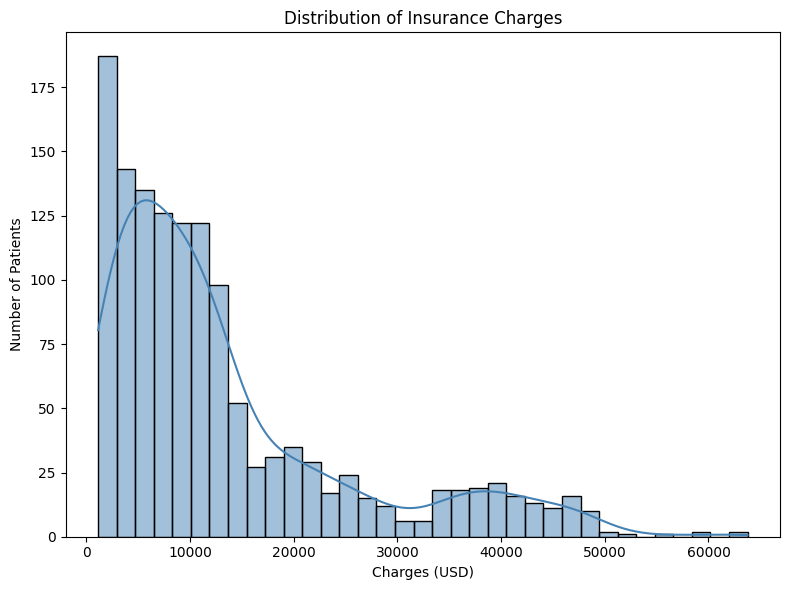

In [ ]:
 # 1. Distribution of Insurance Charges
plt.figure(figsize=(8, 6))
sns.histplot(df['charges'], bins=35, kde=True, color='steelblue')
plt.title('Distribution of Insurance Charges')
plt.xlabel('Charges (USD)')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

In [ ]:
# Visualizing the skewed values in the dataset
df[df['charges'] > 30000]

,age,sex,bmi,children,smoker,region,charges
14,27,male,42.130,0,yes,southeast,39611.75770
19,30,male,35.300,0,yes,southwest,36837.46700
23,34,female,31.920,1,yes,northeast,37701.87680
29,31,male,36.300,2,yes,southwest,38711.00000
30,22,male,35.600,0,yes,southwest,35585.57600
...,...,...,...,...,...,...,...
1301,62,male,30.875,3,yes,northwest,46718.16325
1303,43,male,27.800,0,yes,southwest,37829.72420
1308,25,female,30.200,0,yes,southwest,33900.65300
1313,19,female,34.700,2,yes,southwest,36397.57600


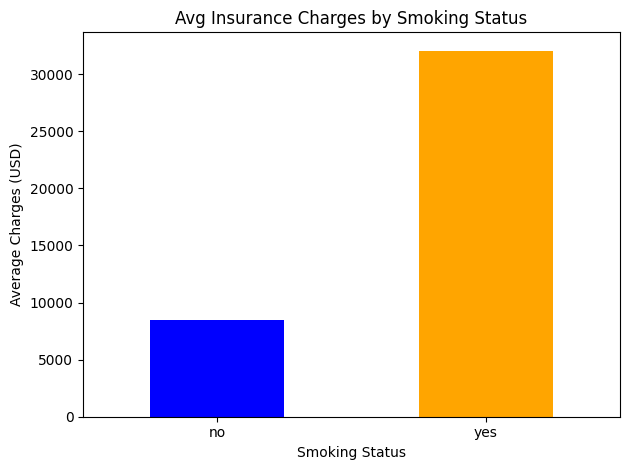

In [ ]:
# 2. Insurance Charges by Smoking Status
df.groupby('smoker')['charges'].mean().plot(kind='bar', color=['blue', 'orange'])
plt.title('Avg Insurance Charges by Smoking Status')
plt.xlabel('Smoking Status')
plt.ylabel('Average Charges (USD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

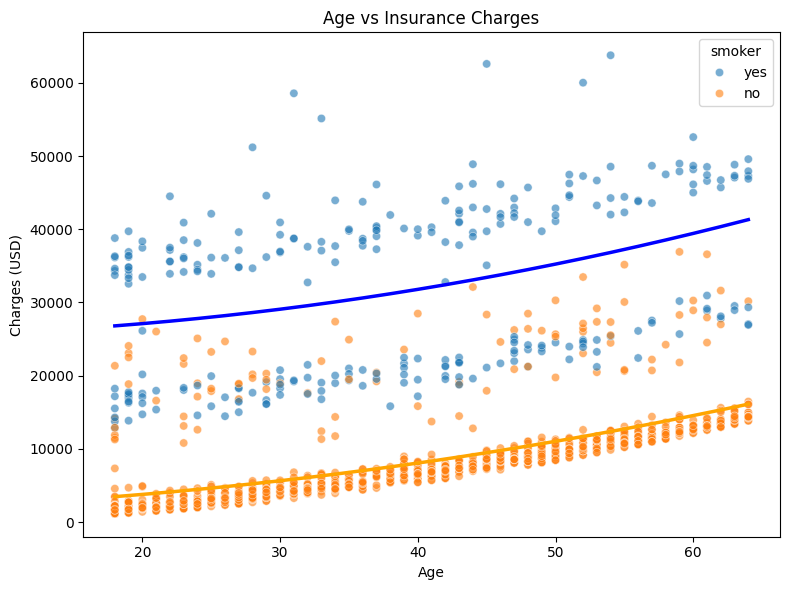

In [ ]:
# 3. Age Vs Insurance Charges
plt.figure(figsize=(8, 6))
sns.scatterplot(x='age', y='charges', data=df, hue='smoker', alpha=0.6)
for group, color in zip(['yes', 'no'], ['blue', 'orange']):
    subset = df[df['smoker'] == group]
    z = np.polyfit(subset['age'], subset['charges'], 2)
    p = np.poly1d(z)
    x_line = np.linspace(subset['age'].min(), subset['age'].max(), 300)
    plt.plot(x_line, p(x_line), color=color, linewidth=2.5)

plt.title('Age vs Insurance Charges')
plt.xlabel('Age')
plt.ylabel('Charges (USD)')
plt.tight_layout()
plt.show()

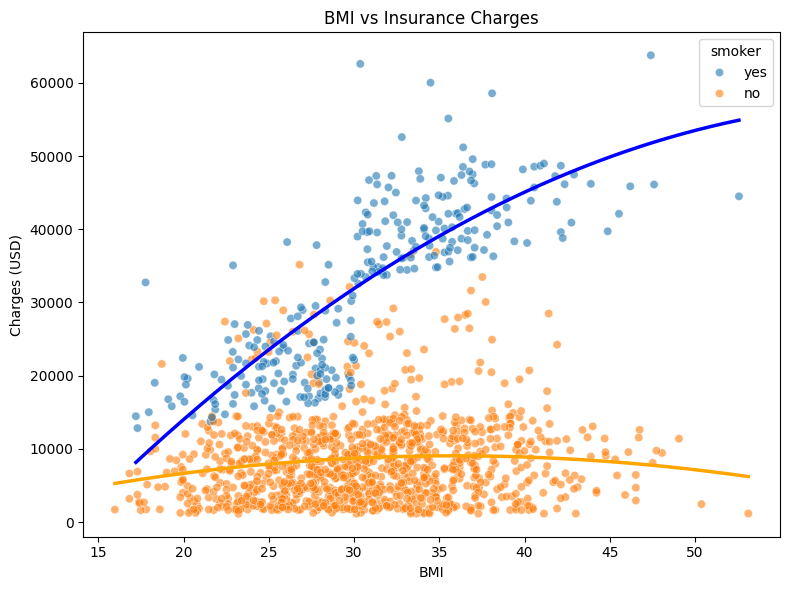

In [ ]:
# 4. BMI Vs Insurance Charges
plt.figure(figsize=(8, 6))
sns.scatterplot(x='bmi', y='charges', data=df, hue='smoker', alpha=0.6)
for group, color in zip(['yes', 'no'], ['blue', 'orange']):
    subset = df[df['smoker'] == group]
    z = np.polyfit(subset['bmi'], subset['charges'], 2)
    p = np.poly1d(z)
    x_line = np.linspace(subset['bmi'].min(), subset['bmi'].max(), 300)
    plt.plot(x_line, p(x_line), color=color, linewidth=2.5)
plt.title('BMI vs Insurance Charges')
plt.xlabel('BMI')
plt.ylabel('Charges (USD)')
plt.tight_layout()
plt.show()

In [ ]:
# combining the
df['high_BMI+smoker'] = ((df['bmi'] > 30 ) & (df['smoker'] == 'yes')).astype(int)
df['high_BMI+smoker']

,high_BMI+smoker
0,0
1,0
2,0
3,0
4,0
...,...
1333,0
1334,0
1335,0
1336,0


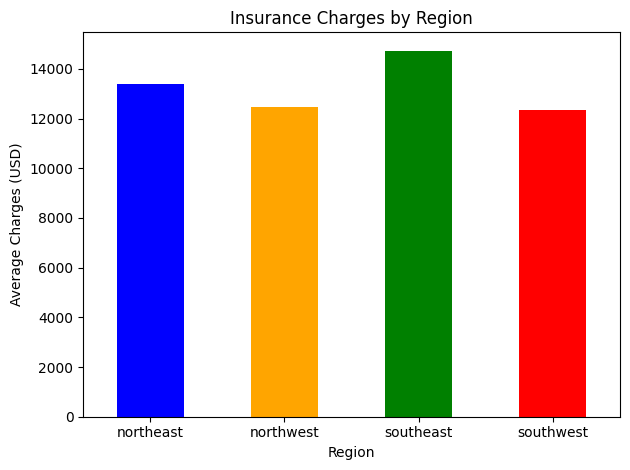

In [ ]:
 # 5. Charges by Region
df.groupby('region')['charges'].mean().plot(kind='bar', color=['blue', 'orange', 'green', 'red'])
plt.title('Insurance Charges by Region')
plt.xlabel('Region')
plt.ylabel('Average Charges (USD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

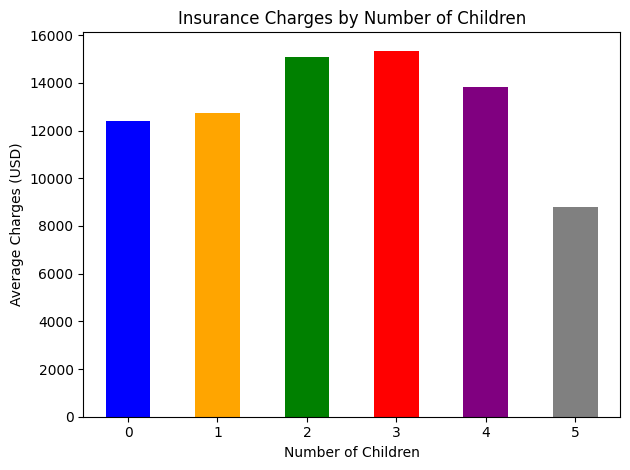

In [ ]:
# 6. Charges by Number of Children
df.groupby('children')['charges'].mean().plot(kind='bar', color=['blue', 'orange', 'green', 'red', 'purple', 'gray'])
plt.title('Insurance Charges by Number of Children')
plt.xlabel('Number of Children')
plt.ylabel('Average Charges (USD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

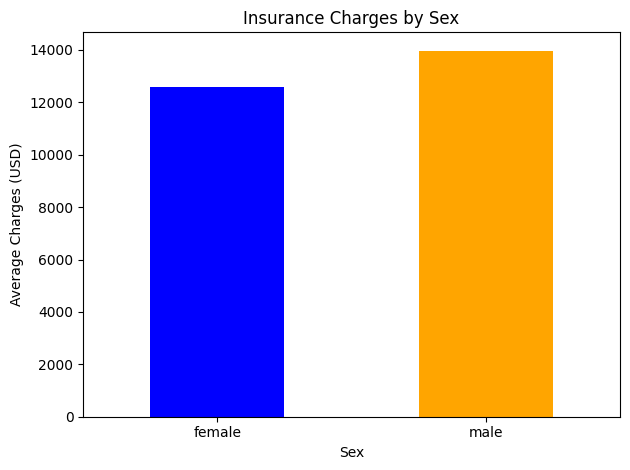

In [ ]:
# 7. Charges by Sex
df.groupby('sex')['charges'].mean().plot(kind='bar', color=['blue', 'orange'])
plt.title('Insurance Charges by Sex')
plt.xlabel('Sex')
plt.ylabel('Average Charges (USD)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

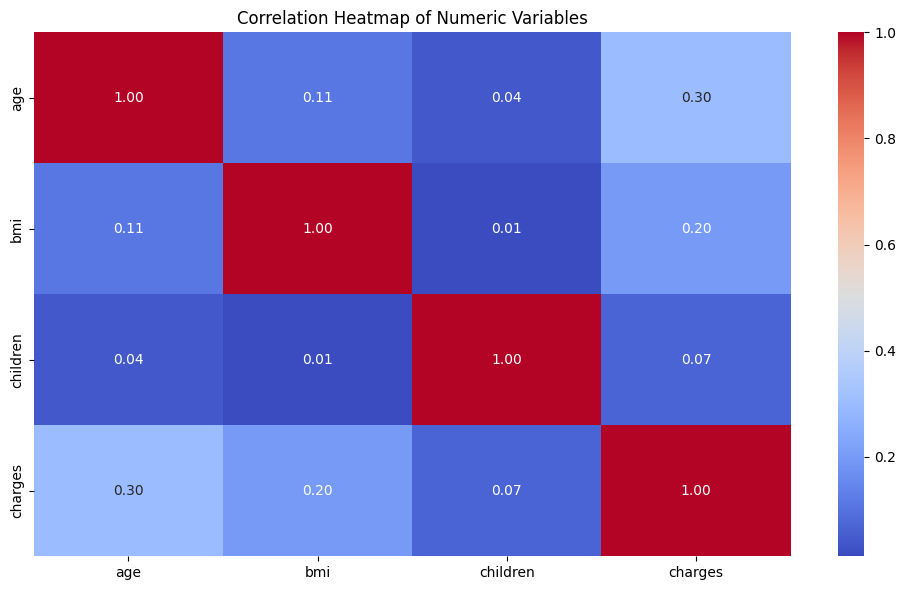

In [ ]:
# 8. Correlation Heatmap
plt.figure(figsize=(10, 6))
numeric_df = df[['age', 'bmi', 'children', 'charges']]
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt= '.2f')
plt.title('Correlation Heatmap of Numeric Variables')
plt.tight_layout()
plt.show()

# **Model Building**

In [ ]:
#encodiing dummies
dummies = pd.get_dummies(df.region)
dummies = dummies.astype(int)
dummies

,northeast,northwest,southeast,southwest
0,0,0,0,1
1,0,0,1,0
2,0,0,1,0
3,0,1,0,0
4,0,1,0,0
...,...,...,...,...
1333,0,1,0,0
1334,1,0,0,0
1335,0,0,1,0
1336,0,0,0,1


In [ ]:
# Merging the dummies with the dataset
mdf = pd.concat([df, dummies], axis = 'columns')
mdf

,age,sex,bmi,children,smoker,region,charges,high_BMI+smoker,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,0,0,0,0,1
1,18,male,33.770,1,no,southeast,1725.55230,0,0,0,1,0
2,28,male,33.000,3,no,southeast,4449.46200,0,0,0,1,0
3,33,male,22.705,0,no,northwest,21984.47061,0,0,1,0,0
4,32,male,28.880,0,no,northwest,3866.85520,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,0,1,0,0
1334,18,female,31.920,0,no,northeast,2205.98080,0,1,0,0,0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0,1,0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0,0,1


In [ ]:
#encoding smoker and sex as binary
mdf.smoker = (mdf.smoker == "yes").astype(int)
mdf.sex = (mdf.sex == "male").astype(int)

mdf

,age,sex,bmi,children,smoker,region,charges,high_BMI+smoker,northeast,northwest,southeast,southwest
0,19,0,27.900,0,1,southwest,16884.92400,0,0,0,0,1
1,18,1,33.770,1,0,southeast,1725.55230,0,0,0,1,0
2,28,1,33.000,3,0,southeast,4449.46200,0,0,0,1,0
3,33,1,22.705,0,0,northwest,21984.47061,0,0,1,0,0
4,32,1,28.880,0,0,northwest,3866.85520,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,northwest,10600.54830,0,0,1,0,0
1334,18,0,31.920,0,0,northeast,2205.98080,0,1,0,0,0
1335,18,0,36.850,0,0,southeast,1629.83350,0,0,0,1,0
1336,21,0,25.800,0,0,southwest,2007.94500,0,0,0,0,1


In [ ]:
#Feature Selection
mdf = mdf.drop(['region', 'southwest'], axis = 'columns')
mdf

,age,sex,bmi,children,smoker,charges,high_BMI+smoker,northeast,northwest,southeast
0,19,0,27.900,0,1,16884.92400,0,0,0,0
1,18,1,33.770,1,0,1725.55230,0,0,0,1
2,28,1,33.000,3,0,4449.46200,0,0,0,1
3,33,1,22.705,0,0,21984.47061,0,0,1,0
4,32,1,28.880,0,0,3866.85520,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...
1333,50,1,30.970,3,0,10600.54830,0,0,1,0
1334,18,0,31.920,0,0,2205.98080,0,1,0,0
1335,18,0,36.850,0,0,1629.83350,0,0,0,1
1336,21,0,25.800,0,0,2007.94500,0,0,0,0


In [ ]:
#Splitting Data into Train and Test sets
from sklearn.model_selection import train_test_split
X = mdf.drop('charges', axis = 'columns')
y = mdf.charges
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 10)
len(X_train), len(X_test)

(1069, 268)

In [ ]:
# Building a Linear Regression model
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [ ]:
# Making predictions on the test set
predictions = model.predict(X_test)
predictions

array([ 4188.88158182,  5010.30643506, 12710.68253324, 10994.96222042,
       42767.00178297,  6316.19299573,  8370.34260983,  3414.15609927,
       42214.16531856, 13726.75196626,  9151.23472234,  5006.17945851,
        2915.25994329, 37984.30347639, 43652.6989745 , 20185.32133471,
        4521.60734727, 10578.81705869,  5115.81844898,  5305.05054941,
       19391.9493827 ,  9675.05869774, 35250.5284256 ,  9212.03779515,
        4108.07508979,  5714.32750096, 40637.2061045 ,  8450.1176925 ,
        5975.08168336,  6534.21984019,  6611.02674014,  9259.73244805,
        7309.98271377, 11412.86531912,  8993.10540133, 12298.75536726,
       14733.69953071,  9373.11966608, 13721.69433409, 13095.61417283,
        3907.79180752, 23331.00959812,  7164.47287826,  2240.12305333,
       11744.23802704, 13178.04789875, 13207.10222024, 42906.47241427,
       43792.5090131 ,  2321.88011287,  9847.13763069, 12400.52210458,
        8721.44559034, 44367.58580434, 10730.29564623, 13203.79983018,
      

In [ ]:
#Getting the model accuracy score
# the model identifies the co-efficient and the intercept then use this to plot a linear graph for preditions
model.score(X_test, y_test)

0.84605282203918